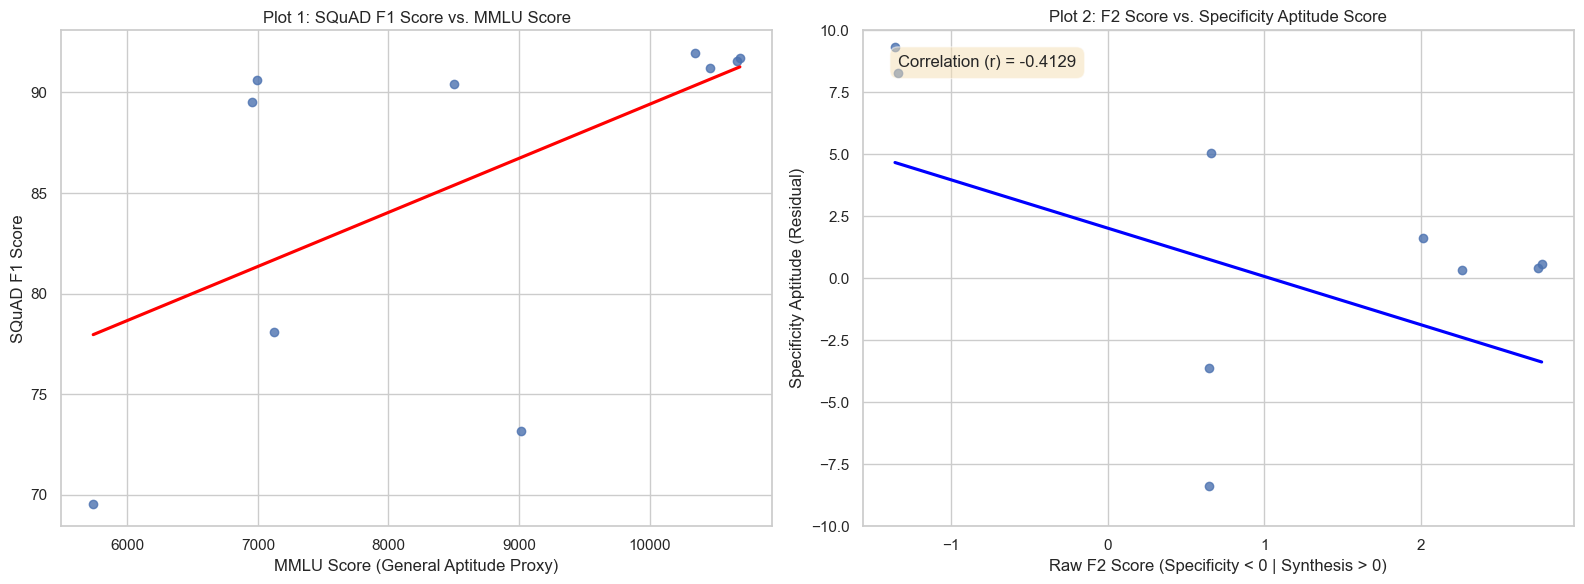

                                 model  f2_raw     mmlu  squad_f1  expected_f1  aptitude_score
1  llama-3.2-11b-vision-instruct-turbo  -1.359   6989.0     90.64    81.324577        9.315423
0          llama-3.1-8b-instruct-turbo  -1.343   6953.0     89.51    81.227907        8.282093
2                           llama-2-7b   0.645   5738.0     69.57    77.965307       -8.395307
3                          llama-2-13b   0.645   7126.0     78.09    81.692458       -3.602458
4                           llama-3-8b   0.662   8502.0     90.44    85.387386        5.052614
5                          llama-2-70b   1.343   9018.0     73.16    86.772984      -13.612984
6                          llama-3-70b   2.015  10346.0     91.96    90.339019        1.620981
7         llama-3.1-70b-instruct-turbo   2.265  10667.0     91.54    91.200990        0.339010
8  llama-3.2-90b-vision-instruct-turbo   2.752  10692.0     91.70    91.268121        0.431879
9         llama-3.3-70b-instruct-turbo   2.774  10

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# 1. Load the final, complete dataset
data = {
    'model': [
        'llama-3.1-8b-instruct-turbo',
        'llama-3.2-11b-vision-instruct-turbo',
        'llama-2-7b',
        'llama-2-13b',
        'llama-3-8b',
        'llama-2-70b',
        'llama-3-70b',
        'llama-3.1-70b-instruct-turbo',
        'llama-3.2-90b-vision-instruct-turbo',
        'llama-3.3-70b-instruct-turbo'
    ],
    'f2_raw': [-1.343, -1.359, 0.645, 0.645, 0.662, 1.343, 2.015, 2.265, 2.752, 2.774],
    'mmlu': [6953.0, 6989.0, 5738.0, 7126.0, 8502.0, 9018.0, 10346.0, 10667.0, 10692.0, 10466.0],
    'squad_f1': [89.51, 90.64, 69.57, 78.09, 90.44, 73.16, 91.96, 91.54, 91.70, 91.23]
}
df = pd.DataFrame(data)

# 2. Model Expected Performance using MMLU as the capability proxy
X = df[['mmlu']]  # <-- Using MMLU as the independent variable
y = df['squad_f1']

# Fit the regression model
reg = LinearRegression().fit(X, y)
df['expected_f1'] = reg.predict(X)

# 3. Calculate the definitive "Specificity Aptitude Score"
df['aptitude_score'] = df['squad_f1'] - df['expected_f1']

# --- Visualization and Conclusion ---

sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 6))

# Plot 1: F1 score vs. MMLU score
plt.subplot(1, 2, 1)
sns.regplot(data=df, x='mmlu', y='squad_f1', ci=None, line_kws={"color": "red"})
plt.title('Plot 1: SQuAD F1 Score vs. MMLU Score')
plt.xlabel('MMLU Score (General Aptitude Proxy)')
plt.ylabel('SQuAD F1 Score')

# Plot 2: The isolated relationship, now using the best proxy
plt.subplot(1, 2, 2)
sns.regplot(data=df, x='f2_raw', y='aptitude_score', ci=None, line_kws={"color": "blue"})
correlation = df['f2_raw'].corr(df['aptitude_score'])
plt.text(0.05, 0.95, f'Correlation (r) = {correlation:.4f}', transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))
plt.title('Plot 2: F2 Score vs. Specificity Aptitude Score')
plt.xlabel('Raw F2 Score (Specificity < 0 | Synthesis > 0)')
plt.ylabel('Specificity Aptitude (Residual)')
plt.ylim(-10, 10)

plt.tight_layout()
plt.show()

print(df.sort_values(by='f2_raw').to_string())

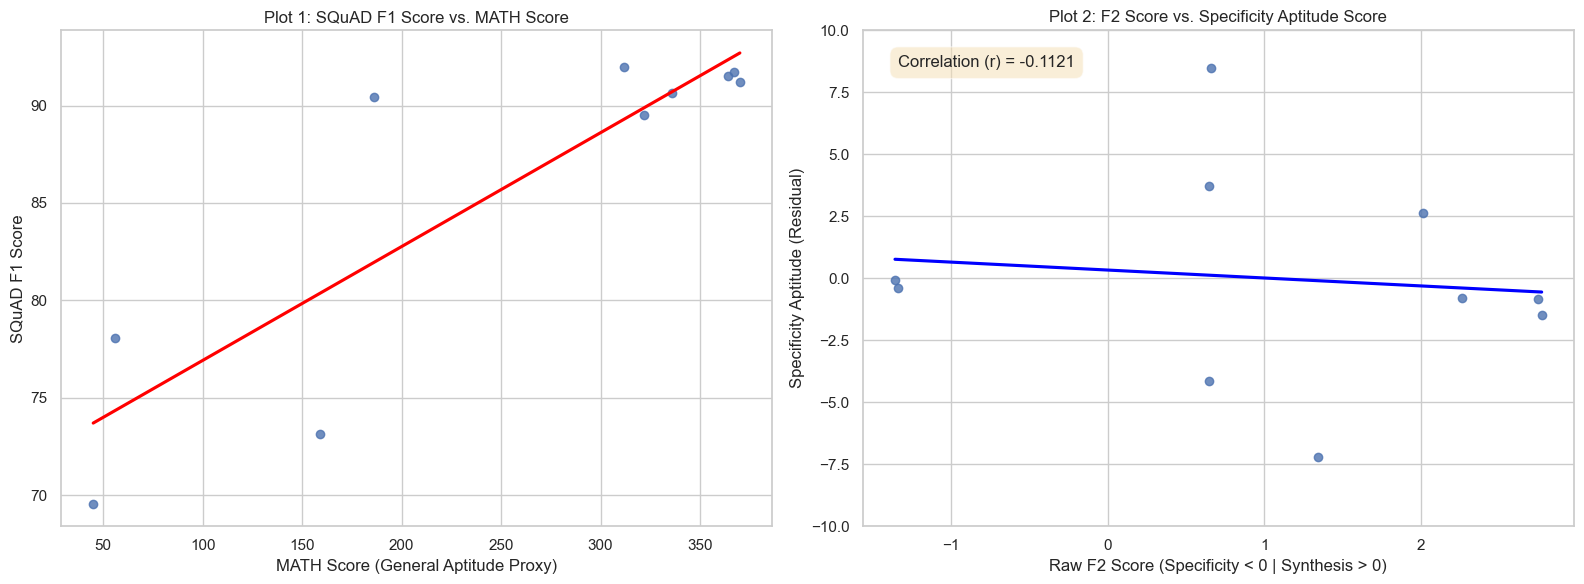

                                 model  f2_raw   math  squad_f1  expected_f1  aptitude_score
1  llama-3.2-11b-vision-instruct-turbo  -1.359  336.0     90.64    90.710573       -0.070573
0          llama-3.1-8b-instruct-turbo  -1.343  322.0     89.51    89.892400       -0.382400
2                           llama-2-7b   0.645   45.0     69.57    73.704253       -4.134253
3                          llama-2-13b   0.645   56.0     78.09    74.347103        3.742897
4                           llama-3-8b   0.662  186.0     90.44    81.944429        8.495571
5                          llama-2-70b   1.343  159.0     73.16    80.366523       -7.206523
6                          llama-3-70b   2.015  312.0     91.96    89.307990        2.652010
7         llama-3.1-70b-instruct-turbo   2.265  364.0     91.54    92.346920       -0.806920
8  llama-3.2-90b-vision-instruct-turbo   2.752  367.0     91.70    92.522243       -0.822243
9         llama-3.3-70b-instruct-turbo   2.774  370.0     91.23    92.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# 1. Load the final, complete dataset
data = {
    'model': [
        'llama-3.1-8b-instruct-turbo',
        'llama-3.2-11b-vision-instruct-turbo',
        'llama-2-7b',
        'llama-2-13b',
        'llama-3-8b',
        'llama-2-70b',
        'llama-3-70b',
        'llama-3.1-70b-instruct-turbo',
        'llama-3.2-90b-vision-instruct-turbo',
        'llama-3.3-70b-instruct-turbo'
    ],
    'f2_raw': [-1.343, -1.359, 0.645, 0.645, 0.662, 1.343, 2.015, 2.265, 2.752, 2.774],
    'math': [322.0, 336.0, 45.0, 56.0, 186.0, 159.0, 312.0, 364.0, 367.0, 370.0],
    'squad_f1': [89.51, 90.64, 69.57, 78.09, 90.44, 73.16, 91.96, 91.54, 91.70, 91.23]
}
df = pd.DataFrame(data)

# 2. Model Expected Performance using MATH as the capability proxy
X = df[['math']]  # <-- Using MATH as the independent variable
y = df['squad_f1']

# Fit the regression model
reg = LinearRegression().fit(X, y)
df['expected_f1'] = reg.predict(X)

# 3. Calculate the definitive "Specificity Aptitude Score"
df['aptitude_score'] = df['squad_f1'] - df['expected_f1']

# --- Visualization and Conclusion ---

sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 6))

# Plot 1: F1 score vs. MATH score
plt.subplot(1, 2, 1)
sns.regplot(data=df, x='math', y='squad_f1', ci=None, line_kws={"color": "red"})
plt.title('Plot 1: SQuAD F1 Score vs. MATH Score')
plt.xlabel('MATH Score (General Aptitude Proxy)')
plt.ylabel('SQuAD F1 Score')

# Plot 2: The isolated relationship, now using the best proxy
plt.subplot(1, 2, 2)
sns.regplot(data=df, x='f2_raw', y='aptitude_score', ci=None, line_kws={"color": "blue"})
correlation = df['f2_raw'].corr(df['aptitude_score'])
plt.text(0.05, 0.95, f'Correlation (r) = {correlation:.4f}', transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))
plt.title('Plot 2: F2 Score vs. Specificity Aptitude Score')
plt.xlabel('Raw F2 Score (Specificity < 0 | Synthesis > 0)')
plt.ylabel('Specificity Aptitude (Residual)')
plt.ylim(-10, 10)

plt.tight_layout()
plt.show()

print(df.sort_values(by='f2_raw').to_string())

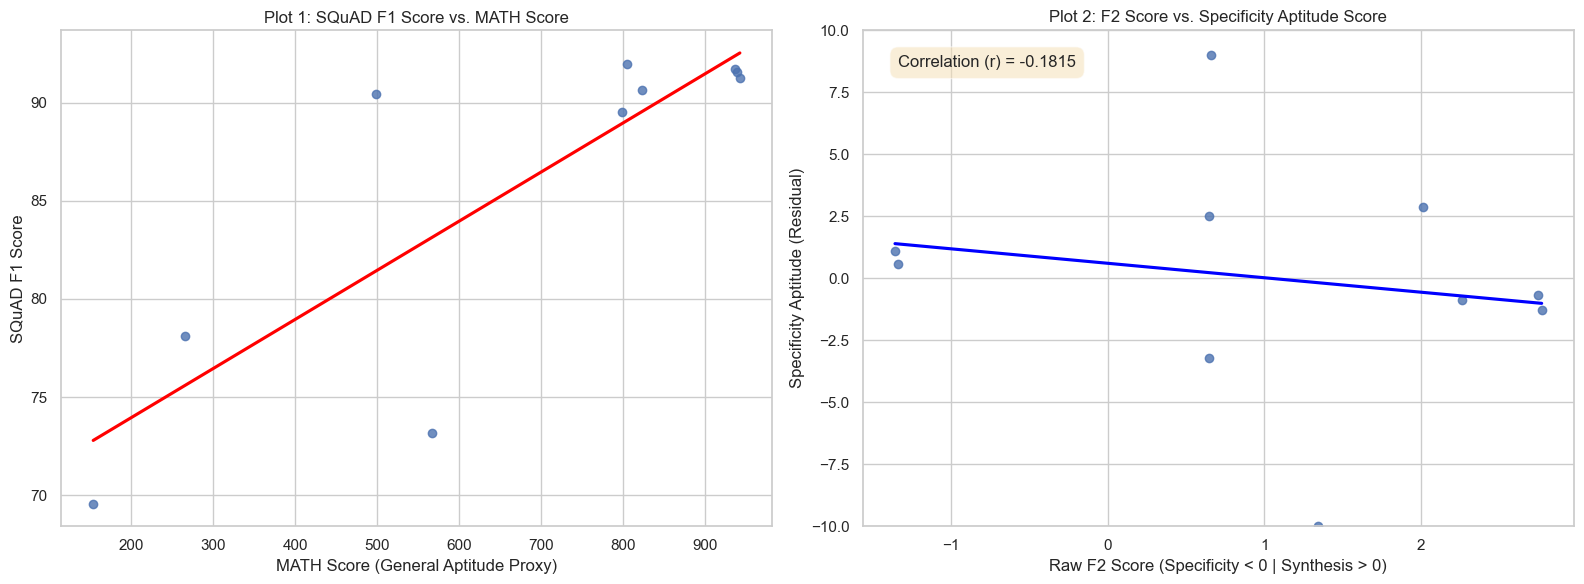

                                 model  f2_raw    gsm  squad_f1  expected_f1  aptitude_score
1  llama-3.2-11b-vision-instruct-turbo  -1.359  823.0     90.64    89.545964        1.094036
0          llama-3.1-8b-instruct-turbo  -1.343  798.0     89.51    88.919805        0.590195
2                           llama-2-7b   0.645  154.0     69.57    72.789945       -3.219945
3                          llama-2-13b   0.645  266.0     78.09    75.595138        2.494862
4                           llama-3-8b   0.662  499.0     90.44    81.430942        9.009058
5                          llama-2-70b   1.343  567.0     73.16    83.134095       -9.974095
6                          llama-3-70b   2.015  805.0     91.96    89.095130        2.864870
7         llama-3.1-70b-instruct-turbo   2.265  938.0     91.54    92.426296       -0.886296
8  llama-3.2-90b-vision-instruct-turbo   2.752  936.0     91.70    92.376203       -0.676203
9         llama-3.3-70b-instruct-turbo   2.774  942.0     91.23    92.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# 1. Load the final, complete dataset
data = {
    'model': [
        'llama-3.1-8b-instruct-turbo',
        'llama-3.2-11b-vision-instruct-turbo',
        'llama-2-7b',
        'llama-2-13b',
        'llama-3-8b',
        'llama-2-70b',
        'llama-3-70b',
        'llama-3.1-70b-instruct-turbo',
        'llama-3.2-90b-vision-instruct-turbo',
        'llama-3.3-70b-instruct-turbo'
    ],
    'f2_raw': [-1.343, -1.359, 0.645, 0.645, 0.662, 1.343, 2.015, 2.265, 2.752, 2.774],
    'gsm': [798.0, 823.0, 154.0, 266.0, 499.0, 567.0, 805.0, 938.0, 936.0, 942.0],
    'squad_f1': [89.51, 90.64, 69.57, 78.09, 90.44, 73.16, 91.96, 91.54, 91.70, 91.23]
}
df = pd.DataFrame(data)

# 2. Model Expected Performance using MATH as the capability proxy
X = df[['gsm']]  # <-- Using MATH as the independent variable
y = df['squad_f1']

# Fit the regression model
reg = LinearRegression().fit(X, y)
df['expected_f1'] = reg.predict(X)

# 3. Calculate the definitive "Specificity Aptitude Score"
df['aptitude_score'] = df['squad_f1'] - df['expected_f1']

# --- Visualization and Conclusion ---

sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 6))

# Plot 1: F1 score vs. MATH score
plt.subplot(1, 2, 1)
sns.regplot(data=df, x='gsm', y='squad_f1', ci=None, line_kws={"color": "red"})
plt.title('Plot 1: SQuAD F1 Score vs. MATH Score')
plt.xlabel('MATH Score (General Aptitude Proxy)')
plt.ylabel('SQuAD F1 Score')

# Plot 2: The isolated relationship, now using the best proxy
plt.subplot(1, 2, 2)
sns.regplot(data=df, x='f2_raw', y='aptitude_score', ci=None, line_kws={"color": "blue"})
correlation = df['f2_raw'].corr(df['aptitude_score'])
plt.text(0.05, 0.95, f'Correlation (r) = {correlation:.4f}', transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))
plt.title('Plot 2: F2 Score vs. Specificity Aptitude Score')
plt.xlabel('Raw F2 Score (Specificity < 0 | Synthesis > 0)')
plt.ylabel('Specificity Aptitude (Residual)')
plt.ylim(-10, 10)

plt.tight_layout()
plt.show()

print(df.sort_values(by='f2_raw').to_string())

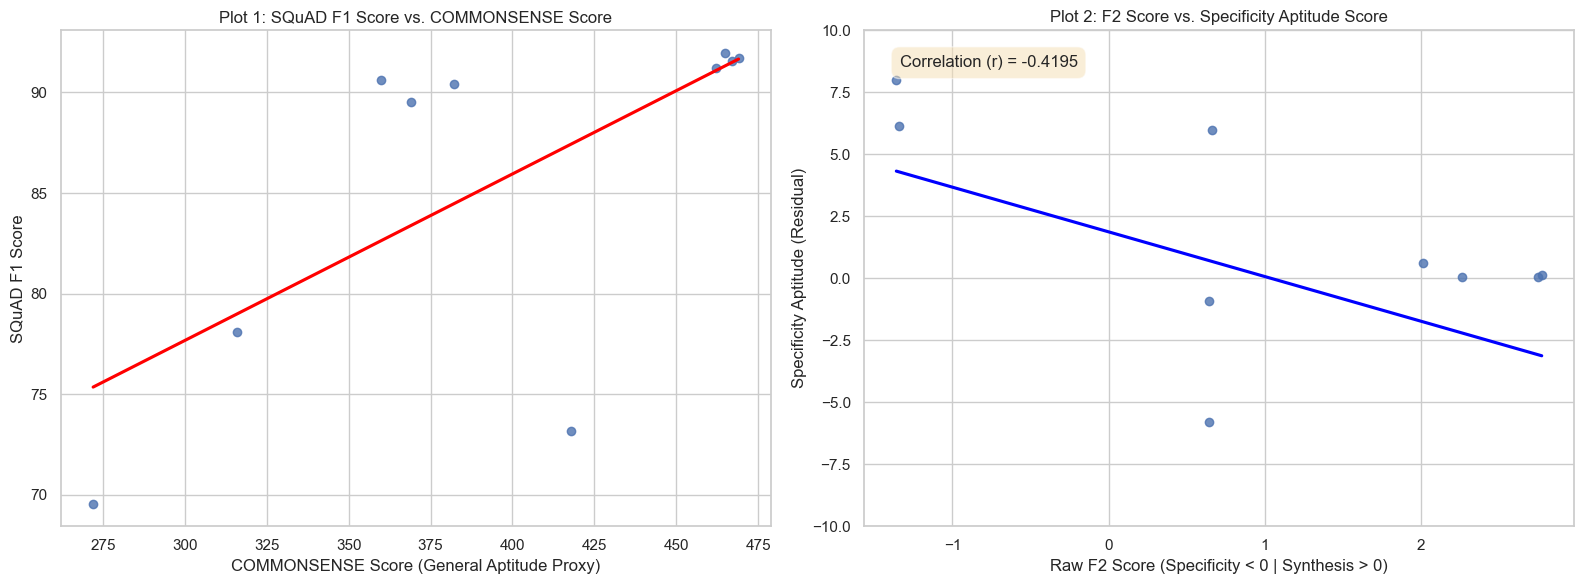

                                 model  f2_raw  commonsense  squad_f1  expected_f1  aptitude_score
1  llama-3.2-11b-vision-instruct-turbo  -1.359        360.0     90.64    82.640531        7.999469
0          llama-3.1-8b-instruct-turbo  -1.343        369.0     89.51    83.385037        6.124963
2                           llama-2-7b   0.645        272.0     69.57    75.360919       -5.790919
3                          llama-2-13b   0.645        316.0     78.09    79.000725       -0.910725
4                           llama-3-8b   0.662        382.0     90.44    84.460434        5.979566
5                          llama-2-70b   1.343        418.0     73.16    87.438457      -14.278457
6                          llama-3-70b   2.015        465.0     91.96    91.326432        0.633568
7         llama-3.1-70b-instruct-turbo   2.265        467.0     91.54    91.491878        0.048122
8  llama-3.2-90b-vision-instruct-turbo   2.752        469.0     91.70    91.657323        0.042677
9         

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# 1. Load the final, complete dataset
data = {
    'model': [
        'llama-3.1-8b-instruct-turbo',
        'llama-3.2-11b-vision-instruct-turbo',
        'llama-2-7b',
        'llama-2-13b',
        'llama-3-8b',
        'llama-2-70b',
        'llama-3-70b',
        'llama-3.1-70b-instruct-turbo',
        'llama-3.2-90b-vision-instruct-turbo',
        'llama-3.3-70b-instruct-turbo'
    ],
    'f2_raw': [-1.343, -1.359, 0.645, 0.645, 0.662, 1.343, 2.015, 2.265, 2.752, 2.774],
    'commonsense': [369.0, 360.0, 272.0, 316.0, 382.0, 418.0, 465.0, 467.0, 469.0, 462.0],
    'squad_f1': [89.51, 90.64, 69.57, 78.09, 90.44, 73.16, 91.96, 91.54, 91.70, 91.23]
}
df = pd.DataFrame(data)

# 2. Model Expected Performance using COMMONSENSE as the capability proxy
X = df[['commonsense']]  # <-- Using COMMONSENSE as the independent variable
y = df['squad_f1']

# Fit the regression model
reg = LinearRegression().fit(X, y)
df['expected_f1'] = reg.predict(X)

# 3. Calculate the definitive "Specificity Aptitude Score"
df['aptitude_score'] = df['squad_f1'] - df['expected_f1']

# --- Visualization and Conclusion ---

sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 6))

# Plot 1: F1 score vs. COMMONSENSE score
plt.subplot(1, 2, 1)
sns.regplot(data=df, x='commonsense', y='squad_f1', ci=None, line_kws={"color": "red"})
plt.title('Plot 1: SQuAD F1 Score vs. COMMONSENSE Score')
plt.xlabel('COMMONSENSE Score (General Aptitude Proxy)')
plt.ylabel('SQuAD F1 Score')

# Plot 2: The isolated relationship, now using the best proxy
plt.subplot(1, 2, 2)
sns.regplot(data=df, x='f2_raw', y='aptitude_score', ci=None, line_kws={"color": "blue"})
correlation = df['f2_raw'].corr(df['aptitude_score'])
plt.text(0.05, 0.95, f'Correlation (r) = {correlation:.4f}', transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))
plt.title('Plot 2: F2 Score vs. Specificity Aptitude Score')
plt.xlabel('Raw F2 Score (Specificity < 0 | Synthesis > 0)')
plt.ylabel('Specificity Aptitude (Residual)')
plt.ylim(-10, 10)

plt.tight_layout()
plt.show()

print(df.sort_values(by='f2_raw').to_string())

# Comparison relative to model size

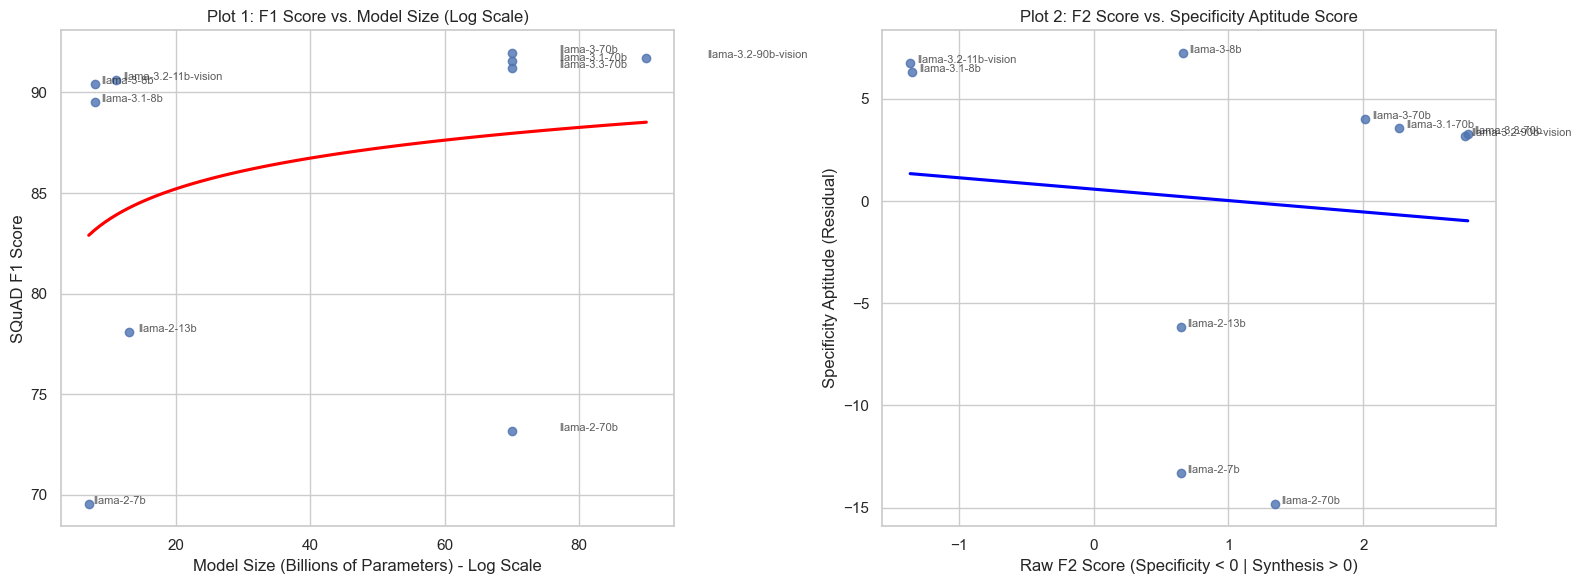


--- Final Data with Aptitude Scores ---
                                 model  size_b  f2_raw  squad_f1  expected_f1  aptitude_score
1  llama-3.2-11b-vision-instruct-turbo      11  -1.359     90.64    83.896067        6.743933
0          llama-3.1-8b-instruct-turbo       8  -1.343     89.51    83.195547        6.314453
2                           llama-2-7b       7   0.645     69.57    82.901811      -13.331811
3                          llama-2-13b      13   0.645     78.09    84.263545       -6.173545
4                           llama-3-8b       8   0.662     90.44    83.195547        7.244453
5                          llama-2-70b      70   1.343     73.16    87.966930      -14.806930
6                          llama-3-70b      70   2.015     91.96    87.966930        3.993070
7         llama-3.1-70b-instruct-turbo      70   2.265     91.54    87.966930        3.573070
8  llama-3.2-90b-vision-instruct-turbo      90   2.752     91.70    88.519760        3.180240
9         llama-3.3

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# 1. Load your data into a pandas DataFrame
# I've combined the data from your F2 score image and the SQuAD F1 scores.
data = {
    'model': [
        'llama-3.1-8b-instruct-turbo',
        'llama-3.2-11b-vision-instruct-turbo',
        'llama-2-7b',
        'llama-2-13b',
        'llama-3-8b',
        'llama-2-70b',
        'llama-3-70b',
        'llama-3.1-70b-instruct-turbo',
        'llama-3.2-90b-vision-instruct-turbo',
        'llama-3.3-70b-instruct-turbo'
    ],
    'size_b': [8, 11, 7, 13, 8, 70, 70, 70, 90, 70],
    'f2_raw': [-1.343, -1.359, 0.645, 0.645, 0.662, 1.343, 2.015, 2.265, 2.752, 2.774],
    'squad_f1': [89.51, 90.64, 69.57, 78.09, 90.44, 73.16, 91.96, 91.54, 91.70, 91.23]
}
df = pd.DataFrame(data)

# 2. Model Expected Performance using Linear Regression
# We'll use the log of model size as a better proxy for capability, as performance
# doesn't scale linearly with parameter count.
X = np.log(df[['size_b']]) 
y = df['squad_f1']

# Fit the regression model
reg = LinearRegression().fit(X, y)
df['expected_f1'] = reg.predict(X)

# 3. Calculate the "Specificity Aptitude Score" (the residual)
# This score shows how much a model over/under-performs for its size.
df['aptitude_score'] = df['squad_f1'] - df['expected_f1']

# --- Visualization and Conclusion ---

# Set up the plotting style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 6))

# Plot 1: The Problem - F1 score is confounded by model size
plt.subplot(1, 2, 1)
sns.regplot(data=df, x='size_b', y='squad_f1', logx=True, ci=None, line_kws={"color": "red"})
# Annotate each point with the model name for clarity
for i in range(df.shape[0]):
    plt.text(df['size_b'][i] * 1.1, df['squad_f1'][i], df['model'][i].replace('meta/llama-', '').replace('-instruct-turbo',''), fontsize=8, alpha=0.75)
plt.title('Plot 1: F1 Score vs. Model Size (Log Scale)')
plt.xlabel('Model Size (Billions of Parameters) - Log Scale')
plt.ylabel('SQuAD F1 Score')

# Plot 2: The Solution - The clear relationship emerges
plt.subplot(1, 2, 2)
sns.regplot(data=df, x='f2_raw', y='aptitude_score', ci=None, line_kws={"color": "blue"})
# Annotate each point
for i in range(df.shape[0]):
    plt.text(df['f2_raw'][i] + 0.05, df['aptitude_score'][i], df['model'][i].replace('meta/llama-', '').replace('-instruct-turbo',''), fontsize=8, alpha=0.75)
plt.title('Plot 2: F2 Score vs. Specificity Aptitude Score')
plt.xlabel('Raw F2 Score (Specificity < 0 | Synthesis > 0)')
plt.ylabel('Specificity Aptitude (Residual)')

plt.tight_layout()
plt.show()

# 4. Print the final DataFrame and Conclusion
print("\n--- Final Data with Aptitude Scores ---")
print(df.sort_values(by='f2_raw').to_string())

print("\n--- Conclusion ---")
print("""
1. Plot 1 clearly shows the problem: SQuAD F1 score generally increases with model size. The red line represents the 'expected' performance for a model of a given size.

2. Plot 2 shows the solution. By plotting the raw F2 score against the 'Specificity Aptitude Score' (the residuals from Plot 1), we isolate the model's tendency.

3. The result is a strong, clear, linear negative correlation. This numerically demonstrates that as a model's F2 score becomes more negative, its specialized aptitude for specificity tasks (like SQuAD) increases dramatically, independent of its general size and power. Conversely, models with high positive F2 scores, like Llama-2-70b, show a strong negative aptitude for this task compared to what their size would predict.
""")

# PCA on SQuAD

In [48]:
# rows: models
# columns: individual SQuAD question IDs
import pandas as pd
from sklearn.decomposition import PCA

df = pd.read_csv('../custom-eval/output/response_matrix.csv', index_col=0)
df_std = (df - df.mean()) / df.std()

pca = PCA(n_components=1)
pc1_scores = pca.fit_transform(df_std.fillna(0))

# pc1_scores is your general ability vector for each model
# Build a cleaned index by extracting the model name from the string index entries.
# Use vectorized string operations on the Index converted to a Series to avoid the AttributeError.
model_index = df.index.to_series().astype(str).str.split('squad_meta-llama__').str[1].str.split('_2025').str[0]

df_models = pd.DataFrame({
    'general_ability_PC1': pc1_scores[:, 0]
}, index=model_index)


In [61]:
model_orders = [
    'Llama-3.1-8B-Instruct',
    'Llama-3.2-11B-Vision-Instruct',
    'Llama-2-7b-chat-hf',
    'Llama-2-13b-chat-hf',
    'Meta-Llama-3-8B-Instruct', # Note the 'Meta-Llama-3' prefix in your data
    'Llama-2-70b-chat-hf',
    'Meta-Llama-3-70B-Instruct', # Note the 'Meta-Llama-3' prefix in your data
    'Llama-3.1-70B-Instruct',
    'Llama-3.2-90B-Vision-Instruct',
    'Llama-3.3-70B-Instruct'
]

print(df_models.loc[model_orders, :]['general_ability_PC1'].tolist())

[9.092083387537224, 9.874245259746534, -31.29606692128061, -13.22557404402188, 8.69443415535372, -24.683863938773435, 10.258554457295102, 10.327398750843361, 10.530188253739807, 10.428600639560155]


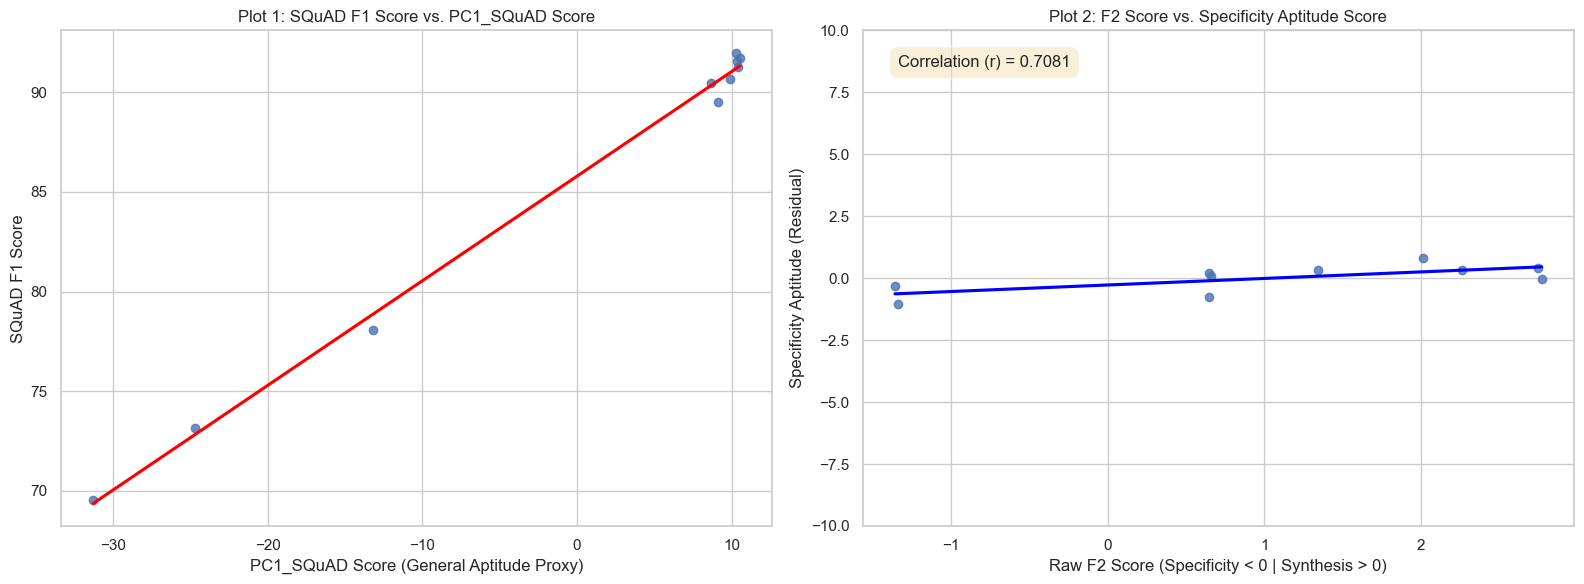

                                 model  f2_raw  pc1_squad  squad_f1  expected_f1  aptitude_score
1  llama-3.2-11b-vision-instruct-turbo  -1.359   9.874245     90.64    90.960945       -0.320945
0          llama-3.1-8b-instruct-turbo  -1.343   9.092083     89.51    90.550867       -1.040867
2                           llama-2-7b   0.645 -31.296067     69.57    69.375858        0.194142
3                          llama-2-13b   0.645 -13.225574     78.09    78.849995       -0.759995
4                           llama-3-8b   0.662   8.694434     90.44    90.342385        0.097615
5                          llama-2-70b   1.343 -24.683864     73.16    72.842555        0.317445
6                          llama-3-70b   2.015  10.258554     91.96    91.162434        0.797566
7         llama-3.1-70b-instruct-turbo   2.265  10.327399     91.54    91.198528        0.341472
8  llama-3.2-90b-vision-instruct-turbo   2.752  10.530188     91.70    91.304848        0.395152
9         llama-3.3-70b-instru

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# 1. Load the final, complete dataset
data = {
    'model': [
        'llama-3.1-8b-instruct-turbo',
        'llama-3.2-11b-vision-instruct-turbo',
        'llama-2-7b',
        'llama-2-13b',
        'llama-3-8b',
        'llama-2-70b',
        'llama-3-70b',
        'llama-3.1-70b-instruct-turbo',
        'llama-3.2-90b-vision-instruct-turbo',
        'llama-3.3-70b-instruct-turbo'
    ],
    'f2_raw': [-1.343, -1.359, 0.645, 0.645, 0.662, 1.343, 2.015, 2.265, 2.752, 2.774],
    'pc1_squad': [9.092083387537224, 9.874245259746534, -31.29606692128061, -13.22557404402188, 8.69443415535372, -24.683863938773435, 10.258554457295102, 10.327398750843361, 10.530188253739807, 10.428600639560155],
    'squad_f1': [89.51, 90.64, 69.57, 78.09, 90.44, 73.16, 91.96, 91.54, 91.70, 91.23]
}
df = pd.DataFrame(data)

# 2. Model Expected Performance using PC1_SQUAD as the capability proxy
X = df[['pc1_squad']]  # <-- Using PC1_SQUAD as the independent variable
y = df['squad_f1']

# Fit the regression model
reg = LinearRegression().fit(X, y)
df['expected_f1'] = reg.predict(X)

# 3. Calculate the definitive "Specificity Aptitude Score"
df['aptitude_score'] = df['squad_f1'] - df['expected_f1']

# --- Visualization and Conclusion ---

sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 6))

# Plot 1: F1 score vs. PC1_SQUAD score
plt.subplot(1, 2, 1)
sns.regplot(data=df, x='pc1_squad', y='squad_f1', ci=None, line_kws={"color": "red"})
plt.title('Plot 1: SQuAD F1 Score vs. PC1_SQuAD Score')
plt.xlabel('PC1_SQuAD Score (General Aptitude Proxy)')
plt.ylabel('SQuAD F1 Score')

# Plot 2: The isolated relationship, now using the best proxy
plt.subplot(1, 2, 2)
sns.regplot(data=df, x='f2_raw', y='aptitude_score', ci=None, line_kws={"color": "blue"})
correlation = df['f2_raw'].corr(df['aptitude_score'])
plt.text(0.05, 0.95, f'Correlation (r) = {correlation:.4f}', transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))
plt.title('Plot 2: F2 Score vs. Specificity Aptitude Score')
plt.xlabel('Raw F2 Score (Specificity < 0 | Synthesis > 0)')
plt.ylabel('Specificity Aptitude (Residual)')
plt.ylim(-10, 10)

plt.tight_layout()
plt.show()

print(df.sort_values(by='f2_raw').to_string())

# PC 1 on legalbench

In [63]:
import pandas as pd

resmat = pd.read_pickle('../data/resmat.pkl')

In [64]:
legalbench = resmat.loc[[
        'meta/llama-3.1-8b-instruct-turbo',
        'meta/llama-3.2-11b-vision-instruct-turbo',
        'meta/llama-2-7b',
        'meta/llama-2-13b',
        'meta/llama-3-8b',
        'meta/llama-2-70b',
        'meta/llama-3-70b',
        'meta/llama-3.1-70b-instruct-turbo',
        'meta/llama-3.2-90b-vision-instruct-turbo',
        'meta/llama-3.3-70b-instruct-turbo'
    ], resmat.columns.get_level_values('scenario') == 'legalbench']

In [78]:
from sklearn.decomposition import PCA

pca = PCA(n_components=1)
pc1_scores = pca.fit_transform(legalbench)

# pc1_scores is your general ability vector for each model
# Build a cleaned index by extracting the model name from the string index entries.
# Use vectorized string operations on the Index converted to a Series to avoid the AttributeError.
model_index = legalbench.index

explained_variance = pca.explained_variance_ratio_[0]
print(f'Explained variance by PC1: {explained_variance:.4f}')

df_models = pd.DataFrame({
    'general_ability_PC1': pc1_scores[:, 0]
}, index=model_index)


Explained variance by PC1: 0.3513


In [71]:
print(df_models['general_ability_PC1'].tolist())

[-5.735303612541937, -12.603958468450733, -10.338379472137586, -8.258821444270787, -7.180719986868726, -2.3834488797932987, 0.25043613278483234, 16.495051840922354, 16.608625610638622, 13.146518279717286]


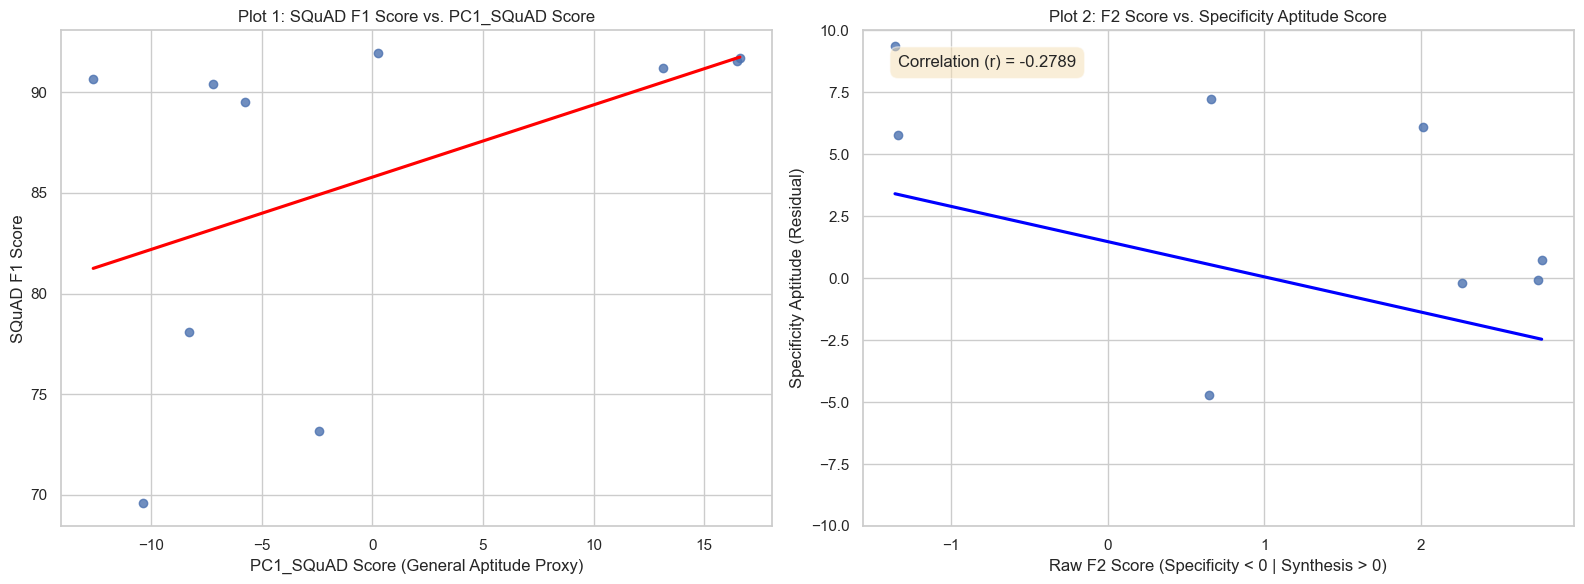

                                 model  f2_raw  pc1_legalbench  squad_f1  expected_f1  aptitude_score
1  llama-3.2-11b-vision-instruct-turbo  -1.359      -12.603958     90.64    81.252891        9.387109
0          llama-3.1-8b-instruct-turbo  -1.343       -5.735304     89.51    83.722165        5.787835
2                           llama-2-7b   0.645      -10.338379     69.57    82.067365      -12.497365
3                          llama-2-13b   0.645       -8.258821     78.09    82.814963       -4.724963
4                           llama-3-8b   0.662       -7.180720     90.44    83.202539        7.237461
5                          llama-2-70b   1.343       -2.383449     73.16    84.927153      -11.767153
6                          llama-3-70b   2.015        0.250436     91.96    85.874032        6.085968
7         llama-3.1-70b-instruct-turbo   2.265       16.495052     91.54    91.713952       -0.173952
8  llama-3.2-90b-vision-instruct-turbo   2.752       16.608626     91.70    91.754

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# 1. Load the final, complete dataset
data = {
    'model': [
        'llama-3.1-8b-instruct-turbo',
        'llama-3.2-11b-vision-instruct-turbo',
        'llama-2-7b',
        'llama-2-13b',
        'llama-3-8b',
        'llama-2-70b',
        'llama-3-70b',
        'llama-3.1-70b-instruct-turbo',
        'llama-3.2-90b-vision-instruct-turbo',
        'llama-3.3-70b-instruct-turbo'
    ],
    'f2_raw': [-1.343, -1.359, 0.645, 0.645, 0.662, 1.343, 2.015, 2.265, 2.752, 2.774],
    'pc1_legalbench': [-5.735303612541937, -12.603958468450733, -10.338379472137586, -8.258821444270787, -7.180719986868726, -2.3834488797932987, 0.25043613278483234, 16.495051840922354, 16.608625610638622, 13.146518279717286],
    'squad_f1': [89.51, 90.64, 69.57, 78.09, 90.44, 73.16, 91.96, 91.54, 91.70, 91.23]
}
df = pd.DataFrame(data)

# 2. Model Expected Performance using PC1_LegalBench as the capability proxy
X = df[['pc1_legalbench']]  # <-- Using PC1_LegalBench as the independent variable
y = df['squad_f1']

# Fit the regression model
reg = LinearRegression().fit(X, y)
df['expected_f1'] = reg.predict(X)

# 3. Calculate the definitive "Specificity Aptitude Score"
df['aptitude_score'] = df['squad_f1'] - df['expected_f1']

# --- Visualization and Conclusion ---

sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 6))

# Plot 1: F1 score vs. PC1_LegalBench score
plt.subplot(1, 2, 1)
sns.regplot(data=df, x='pc1_legalbench', y='squad_f1', ci=None, line_kws={"color": "red"})
plt.title('Plot 1: SQuAD F1 Score vs. PC1_LegalBench Score')
plt.xlabel('PC1_LegalBench Score (General Aptitude Proxy)')
plt.ylabel('SQuAD F1 Score')

# Plot 2: The isolated relationship, now using the best proxy
plt.subplot(1, 2, 2)
sns.regplot(data=df, x='f2_raw', y='aptitude_score', ci=None, line_kws={"color": "blue"})
correlation = df['f2_raw'].corr(df['aptitude_score'])
plt.text(0.05, 0.95, f'Correlation (r) = {correlation:.4f}', transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))
plt.title('Plot 2: F2 Score vs. Specificity Aptitude Score')
plt.xlabel('Raw F2 Score (Specificity < 0 | Synthesis > 0)')
plt.ylabel('Specificity Aptitude (Residual)')
plt.ylim(-10, 10)

plt.tight_layout()
plt.show()

print(df.sort_values(by='f2_raw').to_string())